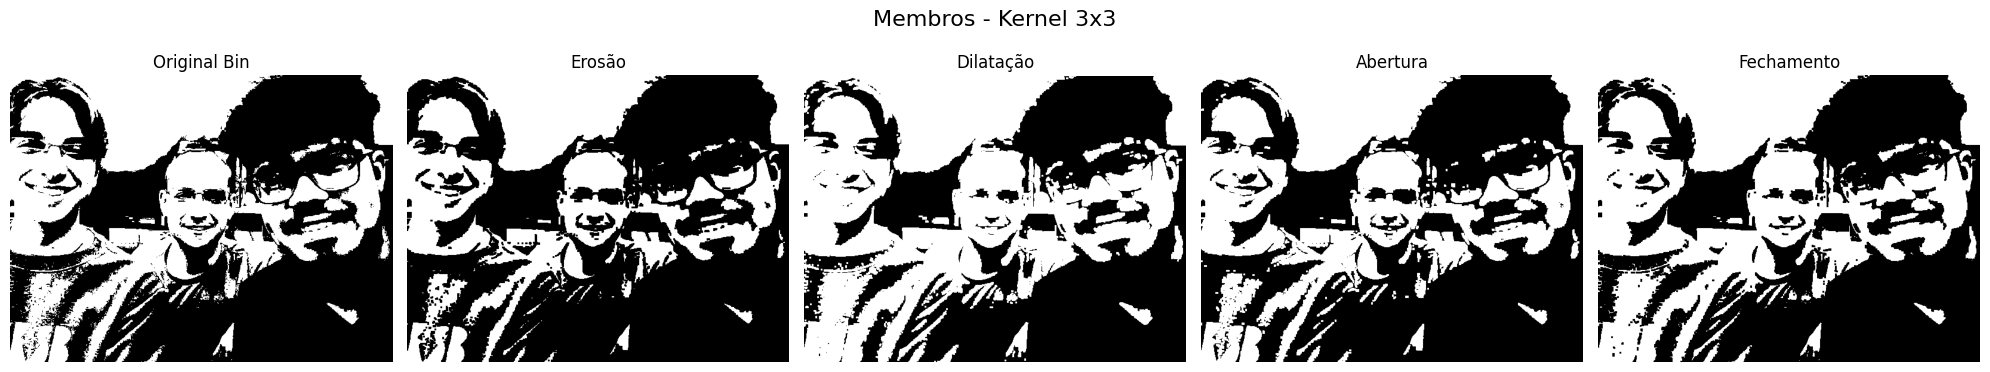

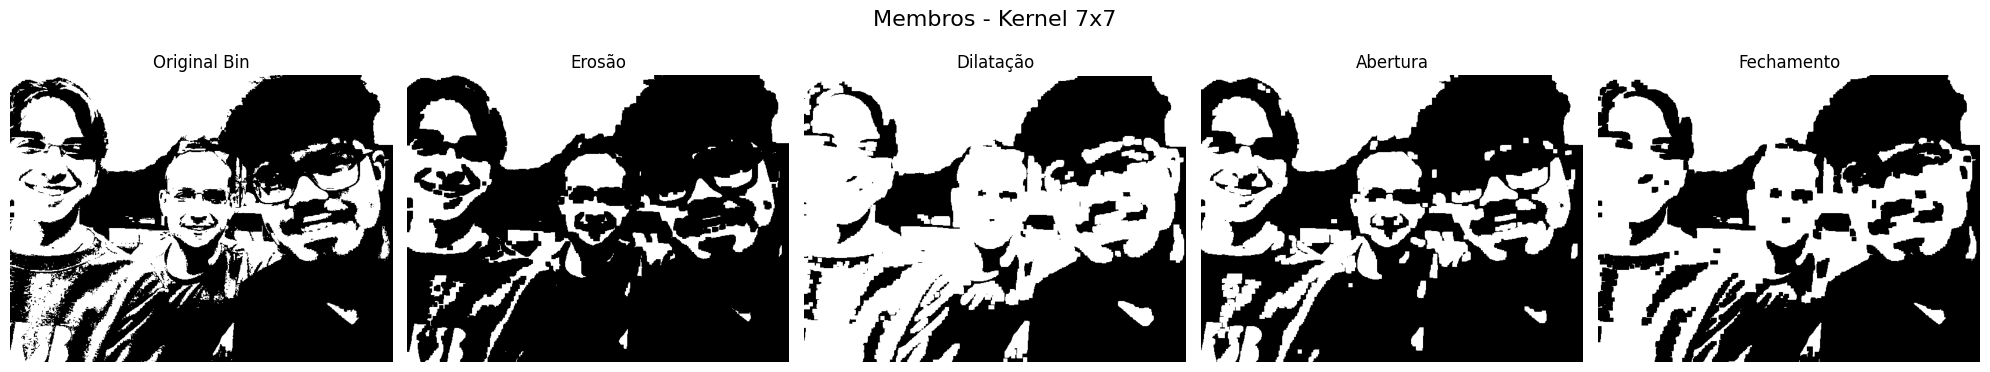

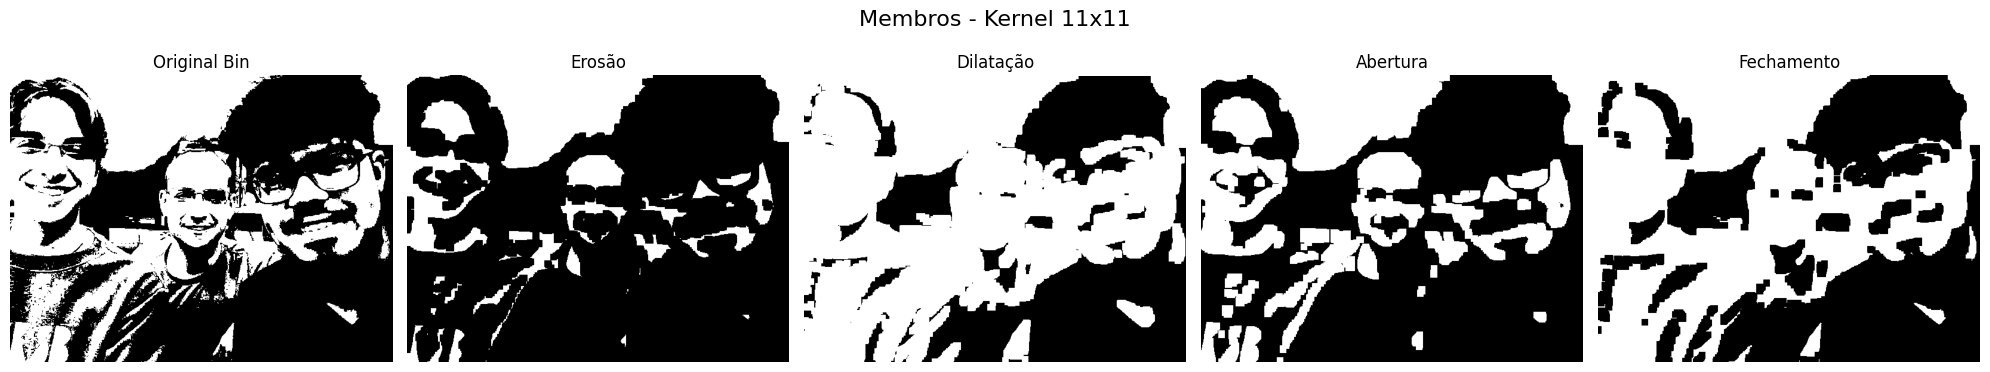

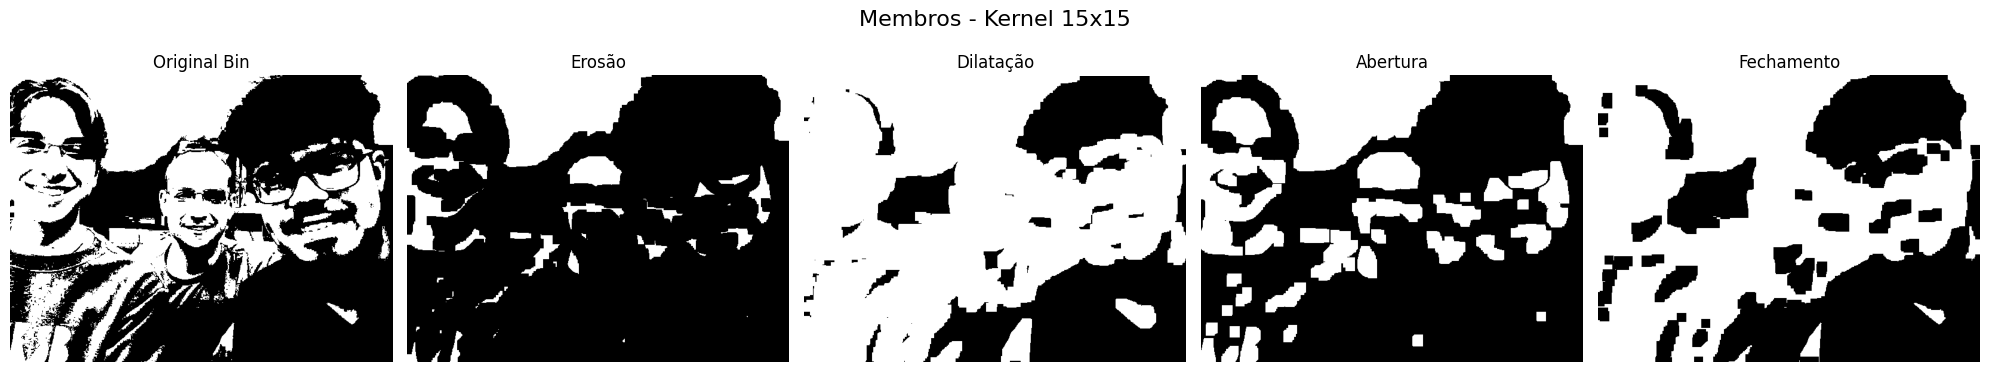

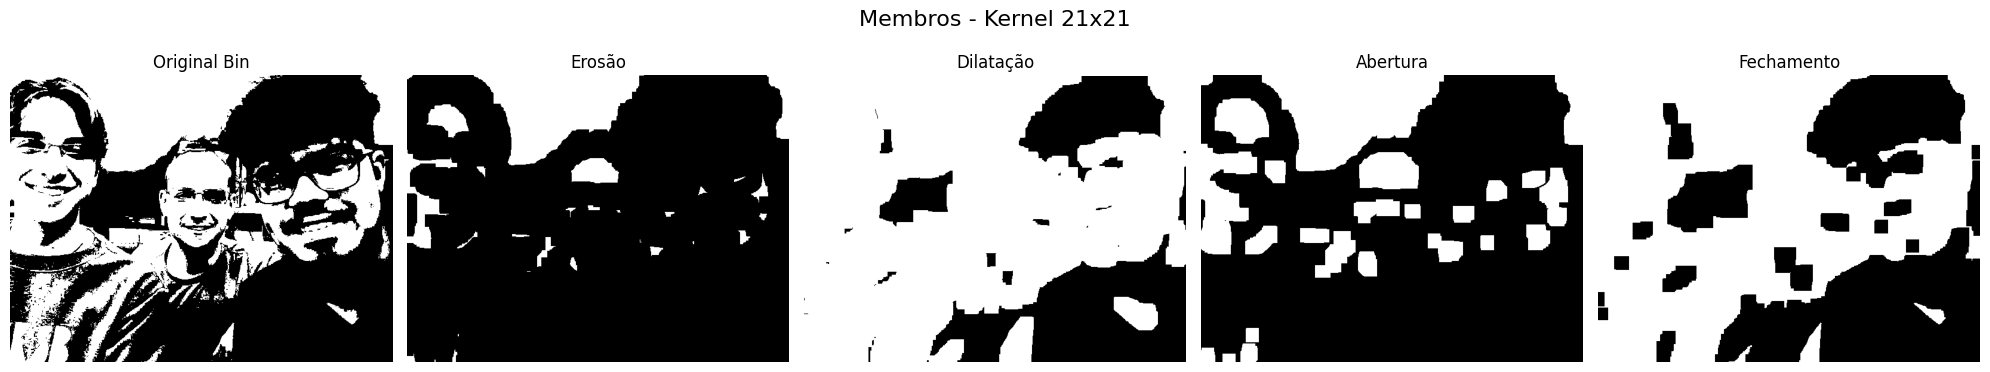

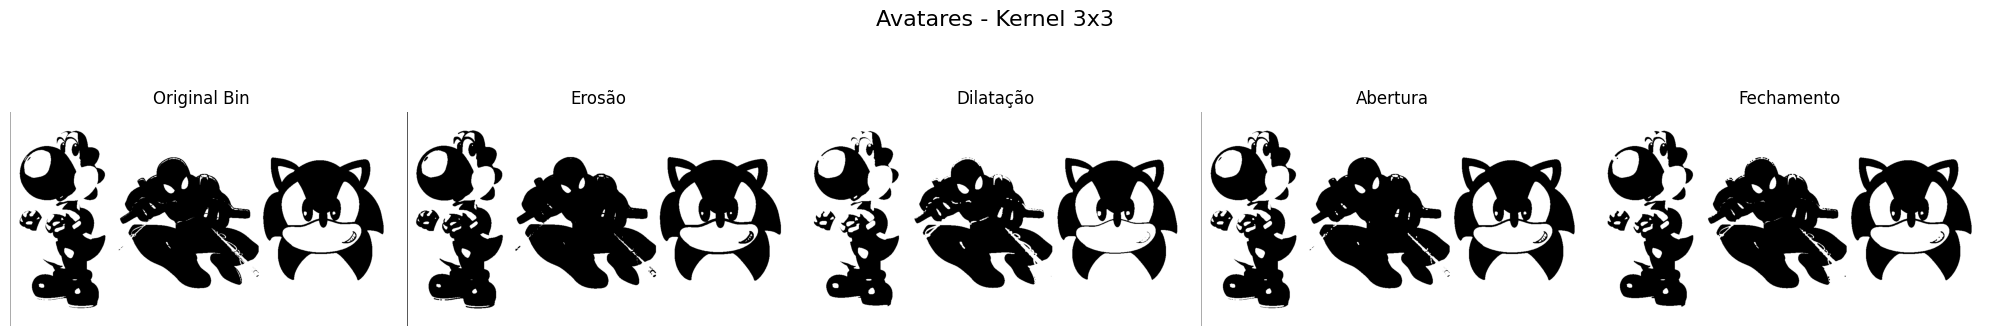

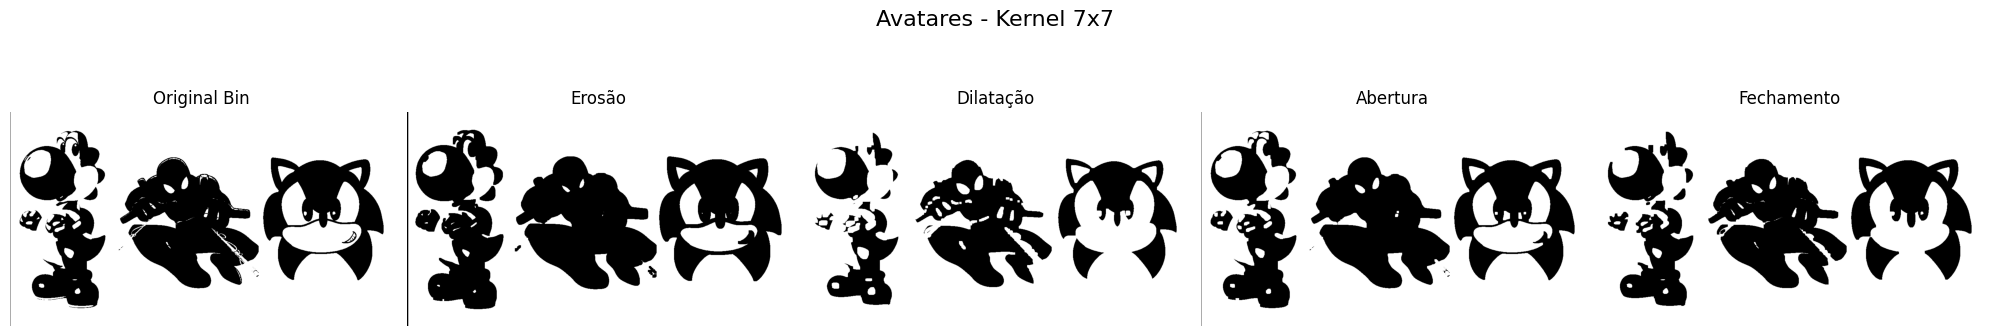

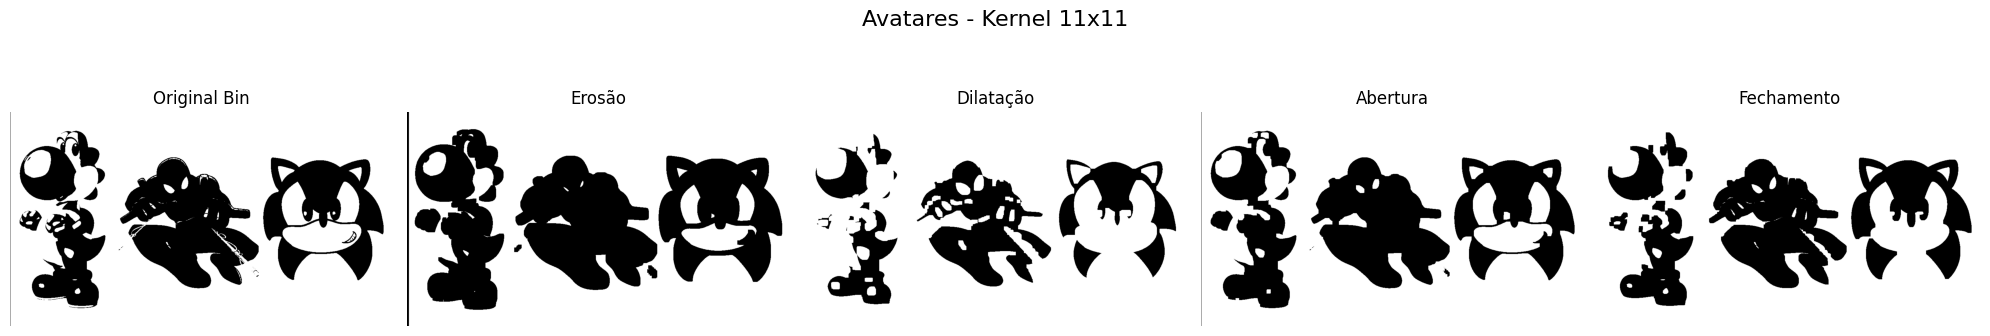

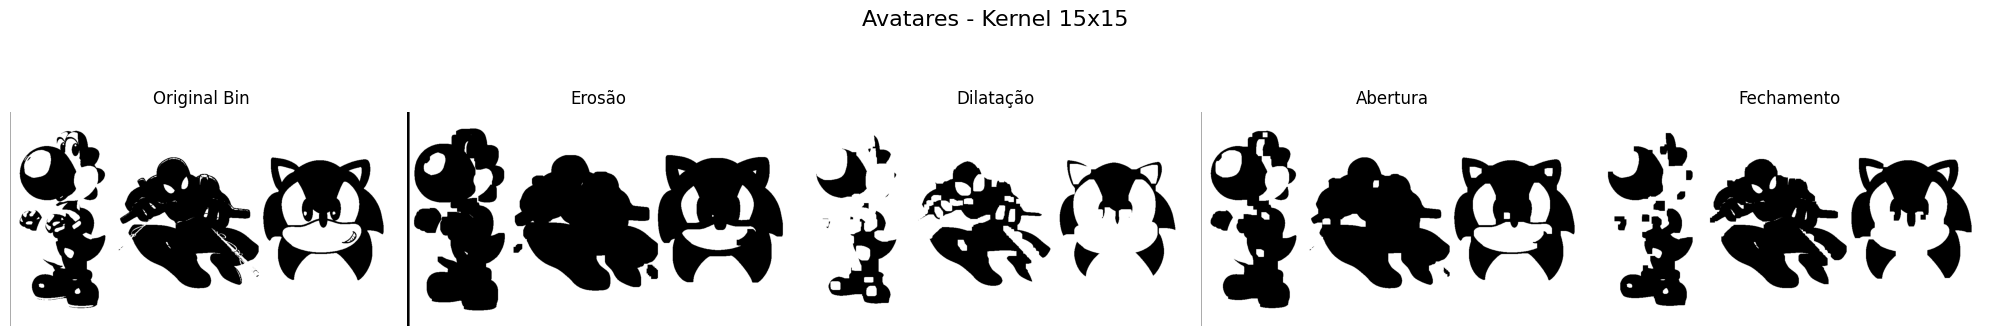

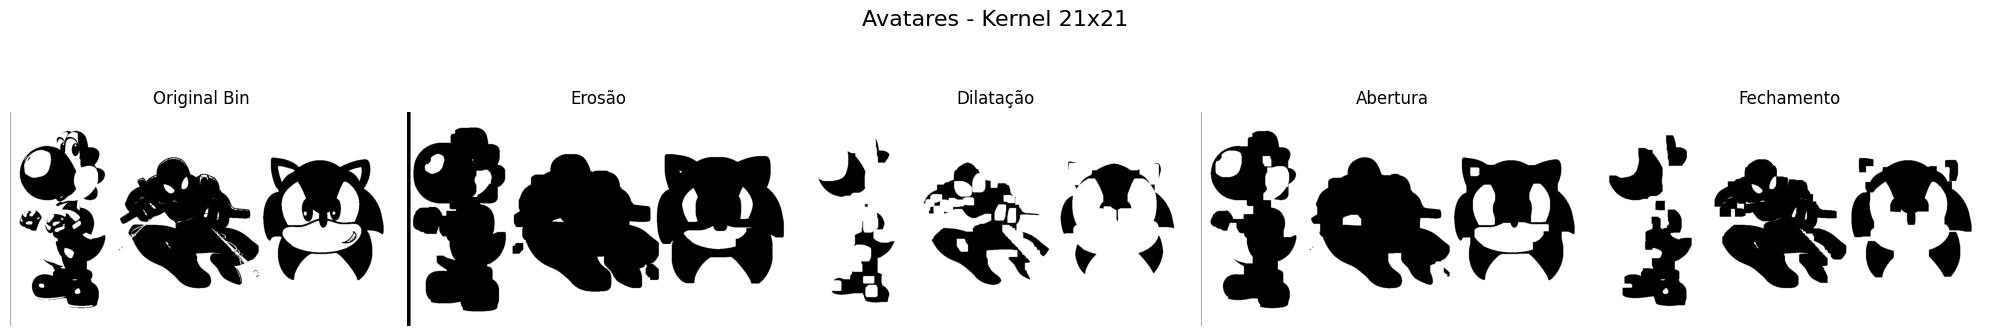

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from morph import *

mm.install()

def exercicio_3a_watershed(path_imagem, titulo, thresh_val=None, noise_k=15):
    img_color = mm.read(path_imagem)
    img_gray = mm.gray(img_color)
    
    img_smooth = cv2.GaussianBlur(img_gray, (noise_k, noise_k), 0)
    
    if thresh_val is None:
        ret, img_bin = cv2.threshold(img_smooth, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        img_bin = mm.threshold(img_smooth, thresh_val)
        img_bin = mm.neg(img_bin)
    
    img_bin = mm.open(img_bin, mm.sedisk(5))
    img_bin = mm.close(img_bin, mm.sedisk(5))

    dist_transform = mm.dist(img_bin)
    
    ret, markers_bin = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
    markers_labeled = mm.label0(np.uint8(markers_bin))
    
    segmentado = mm.watershed(img_color, np.uint8(markers_labeled))
    
    plt.figure(figsize=(15, 5))
    plt.subplot(141), plt.imshow(img_color), plt.title(f'Original: {titulo}')
    plt.subplot(142), plt.imshow(img_bin, 'gray'), plt.title('Limiarização')
    plt.subplot(143), plt.imshow(dist_transform, 'jet'), plt.title('Transf. Distância')
    plt.subplot(144), plt.imshow(segmentado, 'nipy_spectral'), plt.title('Watershed Final')
    plt.show()
    
    return segmentado

res_avatares = exercicio_3a_watershed('images/avatares.png', 'Avatares', thresh_val=240)
res_alunos = exercicio_3a_watershed('images/alunos.png', 'Equipe', noise_k=21)